### 1. 데이터 전처리

In [7]:
# 데이터 로드
import pandas as pd
file_path = "../../data/DieCasting_Quality_Raw_Data.csv"
df_raw = pd.read_csv(file_path, header=[0, 1])

df1 = df_raw[df_raw[('Process', 'Product_Type')] == 1].copy()
df2 = df_raw[df_raw[('Process', 'Product_Type')] == 2].copy()

df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3328 entries, 4207 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   3328 non-null   int64  
 1   (Process, Product_Type)         3328 non-null   int64  
 2   (Process, Shot)                 3328 non-null   int64  
 3   (Process, Velocity_1)           3328 non-null   float64
 4   (Process, Velocity_2)           3328 non-null   float64
 5   (Process, Velocity_3)           3328 non-null   float64
 6   (Process, High_Velocity)        3328 non-null   float64
 7   (Process, Cylinder_Pressure)    3328 non-null   int64  
 8   (Process, Rapid_Rise_Time)      3328 non-null   float64
 9   (Process, Biscuit_Thickness )   3328 non-null   int64  
 10  (Process, Clamping_Force )      3328 non-null   int64  
 11  (Process, Cycle_Time)           3328 non-null   float64
 12  (Process,  Pressure_Rise_Time)  3328 non-n

In [8]:
df2.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  3.328000e+03       3328.0  3328.000000  3328.000000  3328.000000   
mean   5.870842e+06          2.0   341.909856     0.154473     0.168620   
std    9.609260e+05          0.0   198.450612     0.004838     0.004023   
min    4.207011e+06          2.0     0.000000     0.139000     0.158000   
25%    5.038869e+06          2.0   171.000000     0.151500     0.166000   
50%    5.871040e+06          2.0   338.000000     0.156000     0.168000   
75%    6.702476e+06          2.0   508.000000     0.158000     0.172000   
max    7.534661e+06          2.0   732.000000     0.162000     0.178000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  3328.000000   3328.000000       3328.000000     3328.000000   
mean      0.202247      2.553245        264.764123        0.011660   
std       0.004953      0.071882          0.756067        0.000887   
min       0.184000      2.470000        247.000000        0.009000   
25%       0.200000      2.514000        265.000000        0.011000   
50%       0.202000      2.524000        265.000000        0.012000   
75%       0.206000      2.538000        265.000000        0.012000   
max       0.216000      2.744000        266.000000        0.014000   

                          ...      Defects                                     \
      Biscuit_Thickness   ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count        3328.000000  ...  3328.000000  3328.0  3328.000000        3328.0   
mean           17.589243  ...     0.048377     0.0     0.001202           0.0   
std             1.492139  ...     0.222840     0.0     0.034653           0.0   
min             2.000000  ...     0.000000     0.0     0.000000           0.0   
25%            17.000000  ...     0.000000     0.0     0.000000           0.0   
50%            18.000000  ...     0.000000     0.0     0.000000           0.0   
75%            19.000000  ...     0.000000     0.0     0.000000           0.0   
max            24.000000  ...     2.000000     0.0     1.000000           0.0   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     3328.000000  3328.000000  3328.000000    3328.0        3328.0   
mean         0.002404     0.001502     0.000601       0.0           0.0   
std          0.048977     0.038738     0.024511       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  3328.000000  
mean      0.000300  
std       0.017334  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

In [9]:
df2.nunique()

Process  id                      3328
         Product_Type               1
         Shot                     733
         Velocity_1                20
         Velocity_2                16
         Velocity_3                26
         High_Velocity            155
         Cylinder_Pressure          6
         Rapid_Rise_Time            6
         Biscuit_Thickness         14
         Clamping_Force            24
         Cycle_Time                31
          Pressure_Rise_Time       14
         Casting_Pressure          11
         Spray_Time                16
         Spray_1_Time               3
         Spray_2_Time               5
Sensor   Melting_Furnace_Temp     323
         Air_Pressure              26
         Air_Pressure_Min           1
         Air_Pressure_Max           1
         Coolant_Temp              23
         Coolant_Temp_Min           1
         Coolant_Temp_Max           1
         Coolant_Pressure          22
         Factory_Temp              67
         Fac

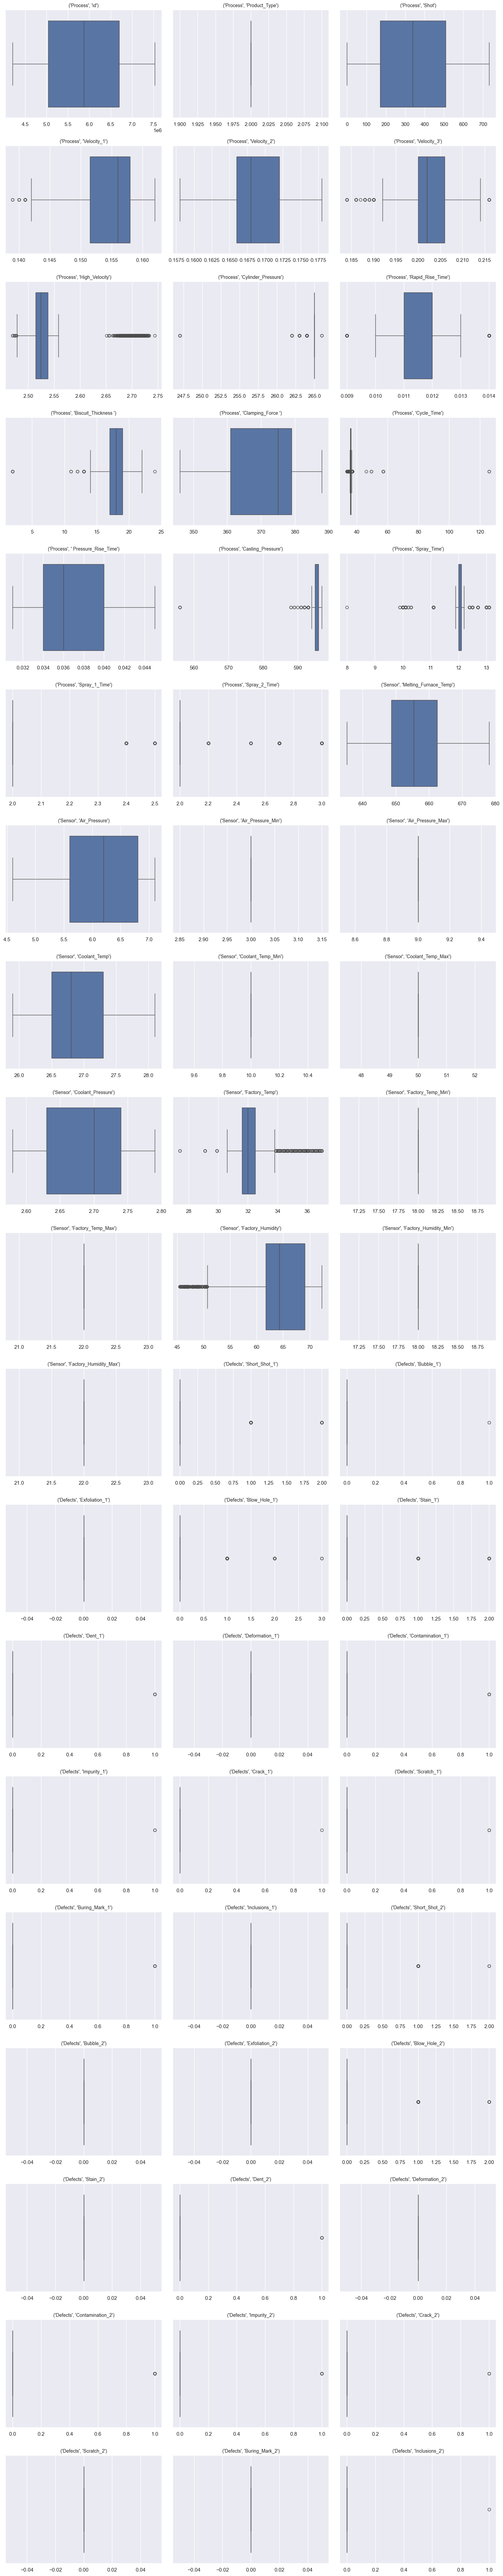

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. 데이터 불러오기 (본인의 파일 경로 및 이름으로 변경해주세요)
# df = pd.read_csv('diecasting_data.csv') 

# 수치형 데이터 컬럼만 추출 (종속 변수나 ID가 있다면 미리 제외하는 것이 좋습니다)
num_cols = df2.select_dtypes(include=['int64', 'float64']).columns

# 2. 그래프 격자 크기 설정
n_cols = 3 # 한 줄에 그릴 그래프 개수 (이미지처럼 3개씩)
n_rows = math.ceil(len(num_cols) / n_cols) # 필요한 줄 수 계산

# 3. 그래프 그리기
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() # 1차원 배열로 평탄화하여 반복문에서 쓰기 쉽게 만듦

# 기본 테마 설정
sns.set_theme(style="darkgrid")

for i, col in enumerate(num_cols):
    # 각 컬럼별로 수평 박스플롯 그리기
    sns.boxplot(x=df2[col], ax=axes[i], color='#4C72B0') 
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('') # x축 라벨 생략 (제목으로 대체)

# 남는 빈 그래프 공간 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()